In [3]:
import sys
!{sys.executable} -m pip install catboost

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

train_data = pd.read_csv(r"C:\Users\divye\Data_science_projects\spaceship_titanic\data\cleaned_train.csv")
test_data = pd.read_csv(r"C:\Users\divye\Data_science_projects\spaceship_titanic\data\cleaned_test.csv")

X = train_data.drop(['Transported','PassengerId'], axis=1)
y = train_data['Transported']

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

print(cat_cols)

encoder = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

X_encoded = encoder.fit_transform(X)
test_encoded = encoder.transform(test_data)

feature_names = encoder.get_feature_names_out()

X_encoded = pd.DataFrame(X_encoded,columns=feature_names)
test_encoded = pd.DataFrame(test_encoded,columns=feature_names)

X_encoded = X_encoded.apply(pd.to_numeric)
test_encoded = test_encoded.apply(pd.to_numeric)

print(X_encoded.shape)
print(test_encoded.shape)




Index(['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup', 'DeckSide'], dtype='object')
(8693, 58)
(4277, 58)


In [5]:
(X_encoded.columns == test_encoded.columns).all()

True

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))

from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

Accuracy: 0.7814836112708453
              precision    recall  f1-score   support

       False       0.80      0.75      0.77       861
        True       0.77      0.82      0.79       878

    accuracy                           0.78      1739
   macro avg       0.78      0.78      0.78      1739
weighted avg       0.78      0.78      0.78      1739



c:\Users\divye\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.7832087406555491


In [8]:
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = XGBClassifier(
   n_estimators=500,     # Number of trees
    max_depth=5,          # Depth of trees (prevents overfitting)
    learning_rate=0.05,   # Step size
    subsample=0.8,        # Use 80% of rows per tree
    colsample_bytree=0.8, # Use 80% of columns per tree
    random_state=42
)

scores = []

for train_idx, val_idx in kf.split(X_encoded, y):
    X_tr, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    acc = (preds == y_val).mean()
    scores.append(acc)

print("CV Accuracy:", np.mean(scores))



CV Accuracy: 0.8095023726319175


In [9]:


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, val_idx in kf.split(X_encoded, y):
    X_tr, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(
        n_estimators=1200,
        learning_rate=0.015,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=2,
        reg_alpha=1,
        reg_lambda=3,
        gamma=0.2,
        random_state=42
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    scores.append((preds == y_val).mean())

print("CV mean:", np.mean(scores))
print("CV std:", np.std(scores))

CV mean: 0.8106535176559415
CV std: 0.008616041365816143


In [10]:
xgb_model = XGBClassifier(
    n_estimators=500,     # Number of trees
    max_depth=5,          # Depth of trees (prevents overfitting)
    learning_rate=0.05,   # Step size
    subsample=0.8,        # Use 80% of rows per tree
    colsample_bytree=0.8, # Use 80% of columns per tree
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 6. Evaluate Model on Validation Set
val_preds = xgb_model.predict(X_val)
acc = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {acc:.4f}")



Validation Accuracy: 0.8918


In [11]:
model = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.015,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    reg_alpha=1,
    reg_lambda=3,
    gamma=0.2,
    random_state=42
)

model.fit(X_encoded, y)
test_probs = model.predict_proba(test_encoded)[:, 1]
test_preds = (test_probs > 0.5).astype(bool)

print(test_preds[:20])

[ True False  True  True  True  True  True  True  True  True False False
  True  True False False False  True  True False]


In [12]:
print("Train distribution:")
print(y.value_counts(normalize=True))

print("\nTest predictions distribution:")
print(pd.Series(test_preds).value_counts(normalize=True))

print("Min:", test_probs.min())
print("Max:", test_probs.max())
print("Mean:", test_probs.mean())

Train distribution:
True     0.503624
False    0.496376
Name: Transported, dtype: float64

Test predictions distribution:
False    0.501286
True     0.498714
dtype: float64
Min: 0.0014847626
Max: 0.99817455
Mean: 0.5033919


Accuracy Rate: 80.97%
Accuracy Rate: 80.16%
Accuracy Rate: 80.97%
Accuracy Rate: 82.68%
Accuracy Rate: 80.55%
CV mean: 0.81065
CV std:  0.00862


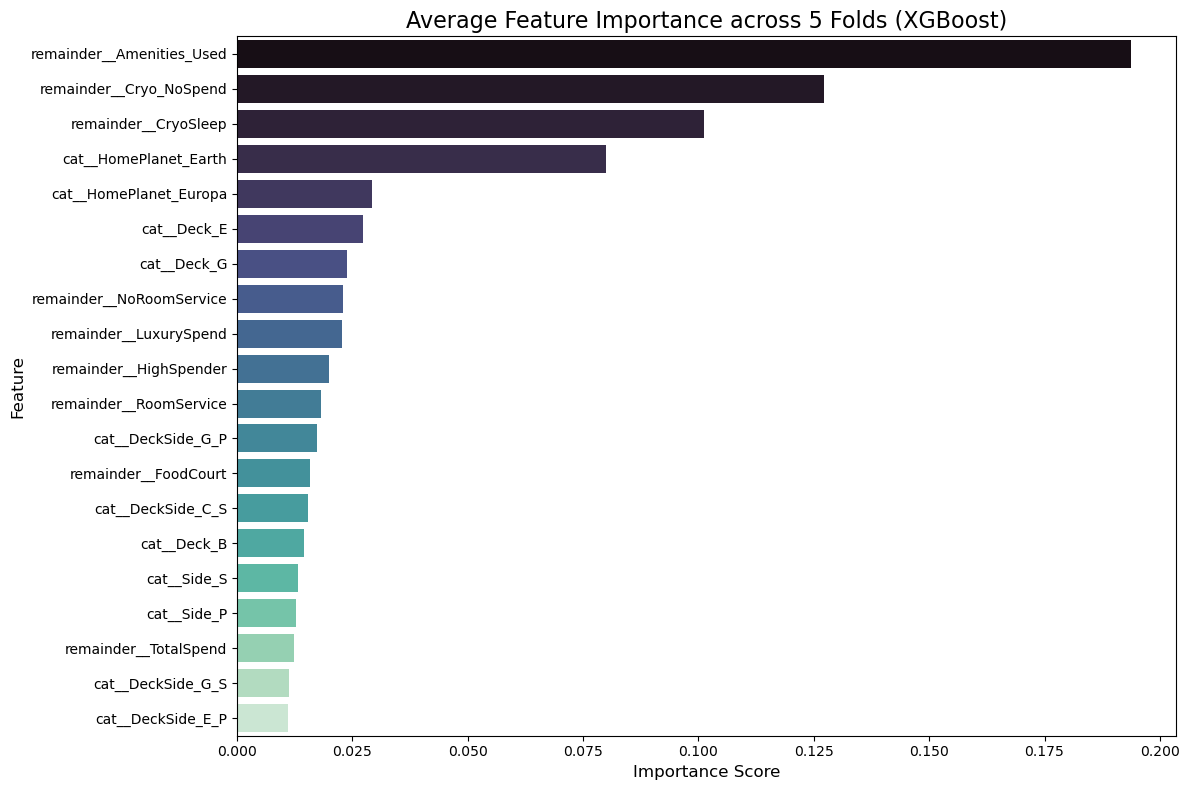

In [13]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
# Create an array of zeros to store the importances
feature_importances = np.zeros(X_encoded.shape[1])

for train_idx, val_idx in kf.split(X_encoded, y):
    X_tr, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(
        n_estimators=1200,
        learning_rate=0.015,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=2,
        reg_alpha=1,
        reg_lambda=3,
        gamma=0.2,
        random_state=42,
        n_jobs=-1 # Uses all CPU cores to train faster
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    acc_rate = accuracy_score(y_val, preds)
    print(f"Accuracy Rate: {acc_rate * 100:.2f}%")
    scores.append((preds == y_val).mean())
    
    # Add the feature importances for this fold (divided by 5 for the average)
    feature_importances += model.feature_importances_ / kf.n_splits

print(f"CV mean: {np.mean(scores):.5f}")
print(f"CV std:  {np.std(scores):.5f}")

# --- Plotting the Top 20 Features ---
importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='mako')
plt.title("Average Feature Importance across 5 Folds (XGBoost)", fontsize=16)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
print("Initializing final model...")
final_model = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.015,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    reg_alpha=1,
    reg_lambda=3,
    gamma=0.2,
    random_state=42,
    n_jobs=-1 
)

# 2. Train on ALL the training data
print("Training final model on 100% of the training data...")
final_model.fit(X_encoded, y)

# 3. Predict on the encoded test data
print("Making predictions on the test set...")
test_predictions = final_model.predict(test_encoded)

# 4. Create the Kaggle Submission DataFrame
# Kaggle expects 'Transported' to be True/False, so we use .astype(bool) to convert 1/0 back
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'], 
    'Transported': test_predictions.astype(bool)
})

# 5. Save the DataFrame to a CSV file
submission_path = r"C:\Users\divye\Data_science_projects\spaceship_titanic\data\submission.csv"
submission.to_csv(submission_path, index=False)

print(f"Success! Submission file saved to: {submission_path}")


Initializing final model...
Training final model on 100% of the training data...
Making predictions on the test set...
Success! Submission file saved to: C:\Users\divye\Data_science_projects\spaceship_titanic\data\submission.csv


In [15]:
import sys 
print(sys.executable)
!"C:\Users\divye\Data_science_projects\spaceship_titanic\venv\Scripts\python.exe" -m pip install ipykernel catboost
!"C:\Users\divye\Data_science_projects\spaceship_titanic\venv\Scripts\python.exe" -m ipykernel install --user --name spaceship_venv --display-name "Python (spaceship_venv)"

c:\Users\divye\anaconda3\python.exe
Installed kernelspec spaceship_venv in C:\Users\divye\AppData\Roaming\jupyter\kernels\spaceship_venv


Fold 1 Accuracy: 0.8102
Fold 2 Accuracy: 0.8108
Fold 3 Accuracy: 0.8114
Fold 4 Accuracy: 0.8303
Fold 5 Accuracy: 0.8015

CatBoost CV mean: 0.812838615370261
CatBoost CV std:  0.009437375949880934

Top 20 Features:
           Feature  Importance
24     LuxurySpend   12.395699
0       HomePlanet   11.146124
10           Group    9.675026
11            Deck    7.408812
22        DeckSide    7.289930
6        FoodCourt    6.319841
5      RoomService    6.037720
13      TotalSpend    5.559584
3              Age    4.575525
7     ShoppingMall    3.799421
21  SpendPerPerson    3.736315
26  Amenities_Used    3.330756
2      Destination    3.220430
8              Spa    2.873254
12            Side    2.716741
9           VRDeck    2.314049
15        AgeGroup    2.280543
1        CryoSleep    1.926703
14    Cryo_NoSpend    1.433478
16       GroupSize    1.251694


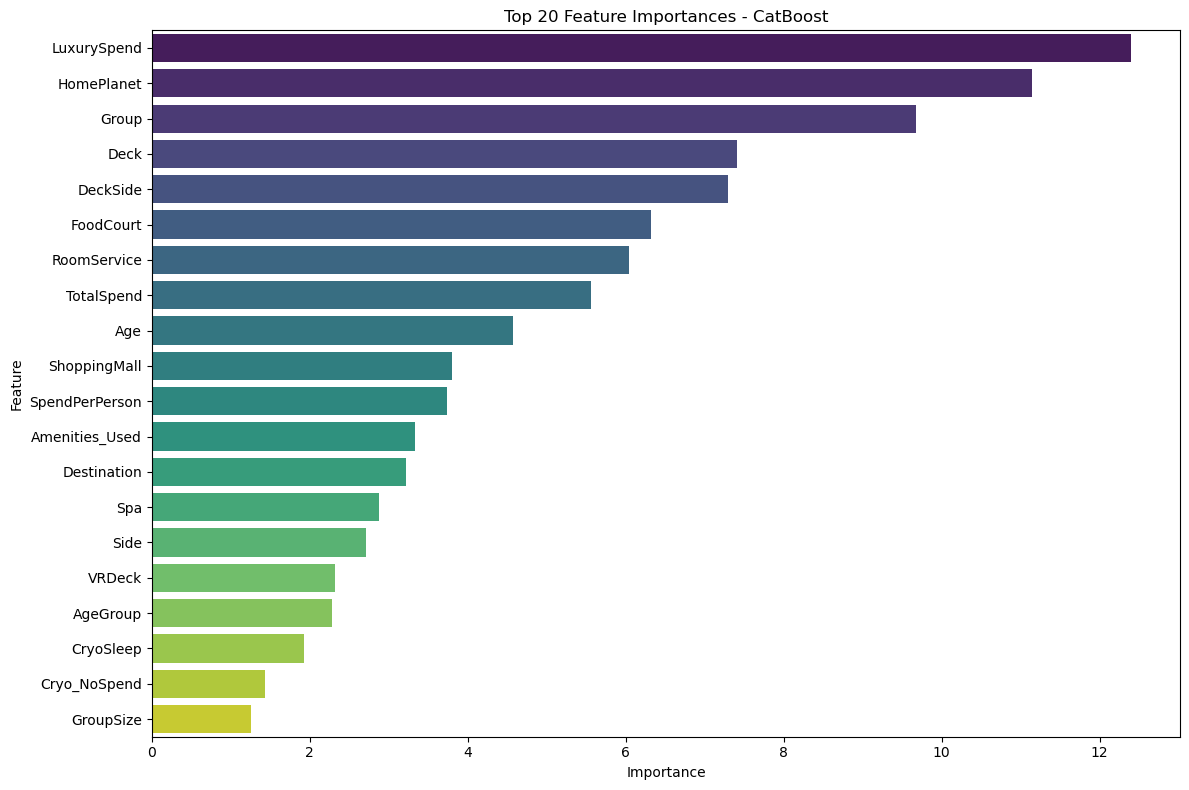

In [17]:
cat_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
feature_importance_list = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        loss_function='Logloss',
        eval_metric='Accuracy',
        random_state=42,
        verbose=0
    )

    model.fit(
        X_tr, y_tr,
        cat_features=cat_features
    )

    preds = model.predict(X_val)
    preds = preds.astype(int).flatten()

    acc = accuracy_score(y_val, preds)
    scores.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")

    feature_importance_list.append(model.get_feature_importance())

print("\nCatBoost CV mean:", np.mean(scores))
print("CatBoost CV std: ", np.std(scores))

# =========================
# Average feature importance
# =========================
avg_feature_importance = np.mean(feature_importance_list, axis=0)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': avg_feature_importance
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Features:")
print(importance_df.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title("Top 20 Feature Importances - CatBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [20]:
final_model = CatBoostClassifier(
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=0
)

final_model.fit(X, y, cat_features=cat_features)
drop_cols = ['PassengerId']
X_test = test_data.drop(columns=[col for col in drop_cols if col in test_data.columns])

# =========================
# Predict on test data
# =========================
test_preds = final_model.predict(X_test)
test_preds = test_preds.astype(int).flatten()

# Convert 0/1 to True/False
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Transported': test_preds.astype(bool)
})

# =========================
# Save submission
# =========================
submission_path = r"C:\Users\divye\Data_science_projects\spaceship_titanic\data\submission_catboost.csv"
submission.to_csv(submission_path, index=False)

print(f"\nSubmission saved successfully at:\n{submission_path}")


Submission saved successfully at:
C:\Users\divye\Data_science_projects\spaceship_titanic\data\submission_catboost.csv
